<a href="https://colab.research.google.com/github/akshaysamuel2812/data-science-project/blob/main/Referral_DS_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
data = 'https://raw.githubusercontent.com/akshaysamuel2812/data-science-project/refs/heads/main/cleaned_uk_police_crime_data.csv'
df = pd.read_csv(data)
df.head()

,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Month_Num,Year
0,01-03-2024,British Transport Police,British Transport Police,-0.577943,50.829352,On or near Ford (Station),E01031470,Arun 006A,Drugs,3,2024
1,01-03-2024,British Transport Police,British Transport Police,0.875301,51.143228,On or near Ashford International (Station),E01034986,Ashford 005G,Drugs,3,2024
2,01-03-2024,British Transport Police,British Transport Police,0.872527,51.142929,On or near Ashford(Kent) (Station),E01034986,Ashford 005G,Drugs,3,2024
3,01-03-2024,British Transport Police,British Transport Police,0.875301,51.143228,On or near Ashford International (Station),E01034986,Ashford 005G,Vehicle crime,3,2024
4,01-03-2024,British Transport Police,British Transport Police,-0.194114,51.649570,On or near High Barnet (Lu Station),E01000288,Barnet 004C,Vehicle crime,3,2024


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('cleaned_uk_police_crime_data.csv')
df['Month'] = pd.to_datetime(df['Month'])
print("Dataset Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Saving cleaned_uk_police_crime_data.csv to cleaned_uk_police_crime_data.csv
Dataset Shape: (29662, 11)

Missing values:
 Month              0
Reported by        0
Falls within       0
Longitude          0
Latitude           0
Location           0
LSOA code       1069
LSOA name       1069
Crime type         0
Month_Num          0
Year               0
dtype: int64


,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Month_Num,Year
0,2024-01-03,British Transport Police,British Transport Police,-0.577943,50.829352,On or near Ford (Station),E01031470,Arun 006A,Drugs,3,2024
1,2024-01-03,British Transport Police,British Transport Police,0.875301,51.143228,On or near Ashford International (Station),E01034986,Ashford 005G,Drugs,3,2024
2,2024-01-03,British Transport Police,British Transport Police,0.872527,51.142929,On or near Ashford(Kent) (Station),E01034986,Ashford 005G,Drugs,3,2024
3,2024-01-03,British Transport Police,British Transport Police,0.875301,51.143228,On or near Ashford International (Station),E01034986,Ashford 005G,Vehicle crime,3,2024
4,2024-01-03,British Transport Police,British Transport Police,-0.194114,51.649570,On or near High Barnet (Lu Station),E01000288,Barnet 004C,Vehicle crime,3,2024


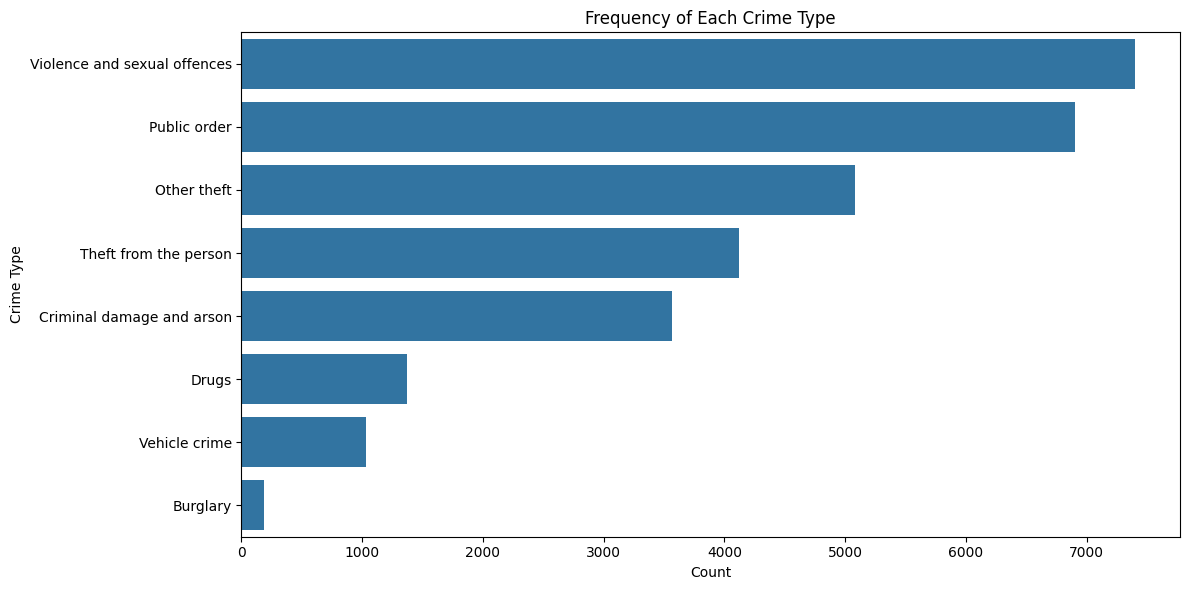

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.countplot(y='Crime type', data=df, order=df['Crime type'].value_counts().index)
plt.title('Frequency of Each Crime Type')
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

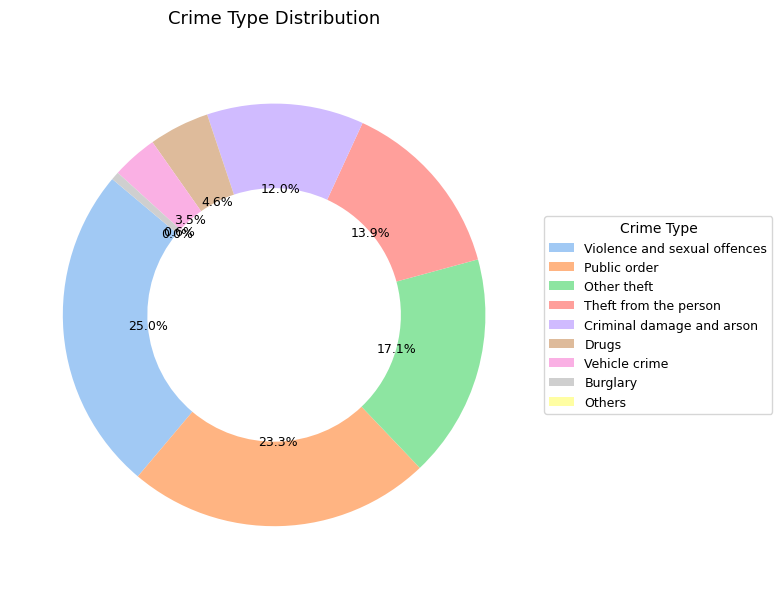

In [ ]:
crime_counts = df['Crime type'].value_counts()
top_crimes = crime_counts[:8]
others = pd.Series([crime_counts[8:].sum()], index=['Others'])
crime_counts_clean = pd.concat([top_crimes, others])
plt.figure(figsize=(9,6))
colors = sns.color_palette('pastel', len(crime_counts_clean))
wedges, texts, autotexts = plt.pie(
    crime_counts_clean,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 9},
    wedgeprops=dict(width=0.4)
)
plt.legend(
    wedges,
    crime_counts_clean.index,
    title="Crime Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)
plt.title('Crime Type Distribution', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

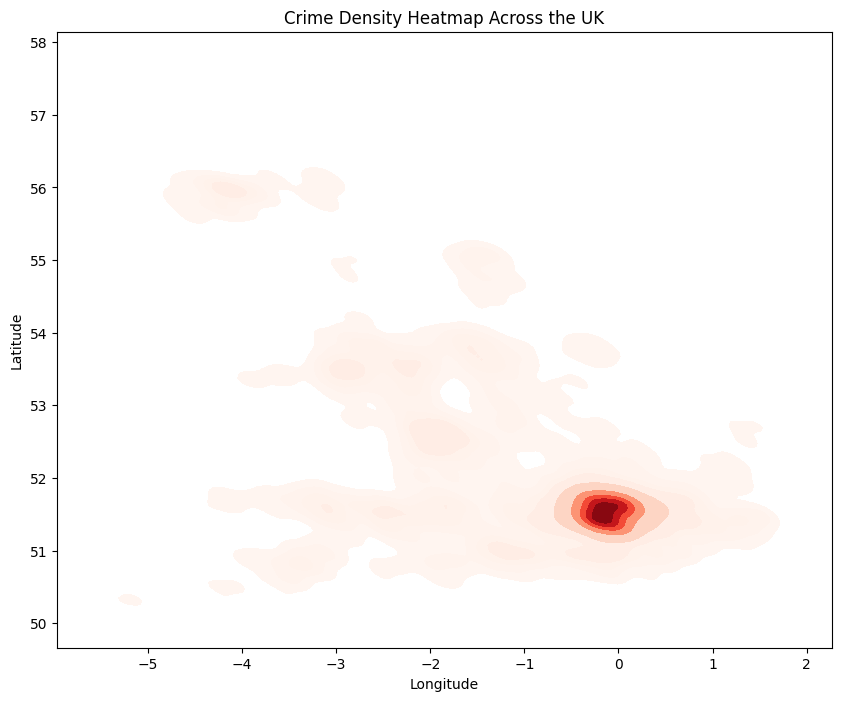

In [ ]:
plt.figure(figsize=(10,8))
sns.kdeplot(x=df['Longitude'], y=df['Latitude'], fill=True, cmap='Reds', bw_adjust=0.5)
plt.title('Crime Density Heatmap Across the UK')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

/tmp/ipython-input-1124759076.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




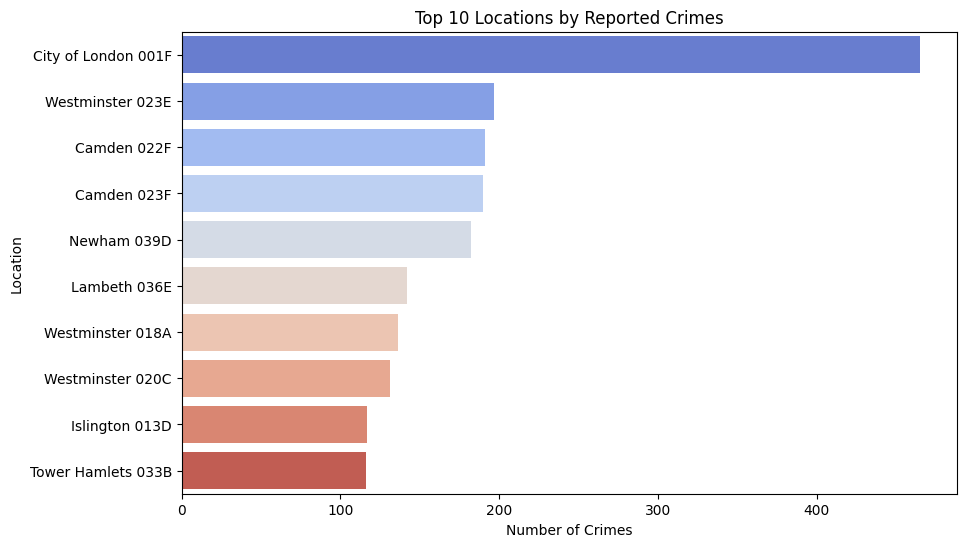

In [ ]:
top_locations = df['LSOA name'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=top_locations.index, x=top_locations.values, palette='coolwarm')
plt.title('Top 10 Locations by Reported Crimes')
plt.xlabel('Number of Crimes')
plt.ylabel('Location')
plt.show()

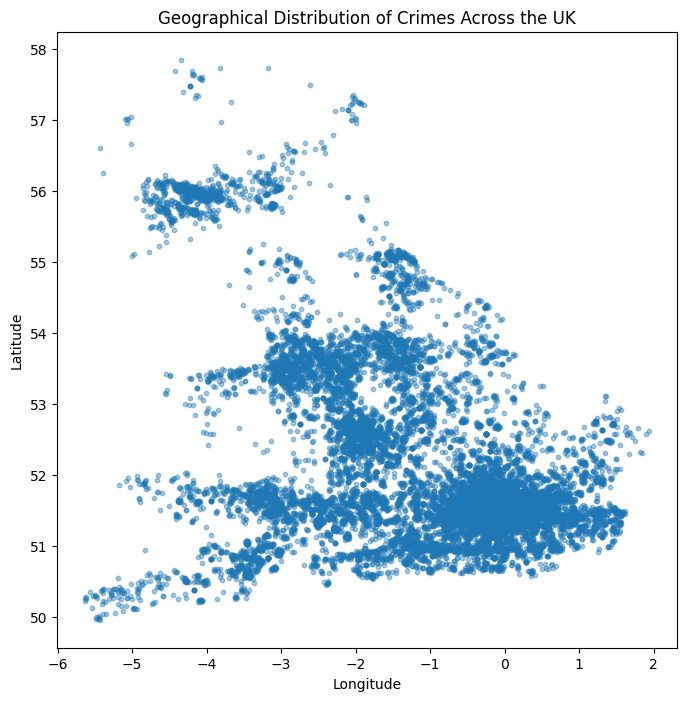

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4, s=10)
plt.title('Geographical Distribution of Crimes Across the UK')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

/tmp/ipython-input-1628592754.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




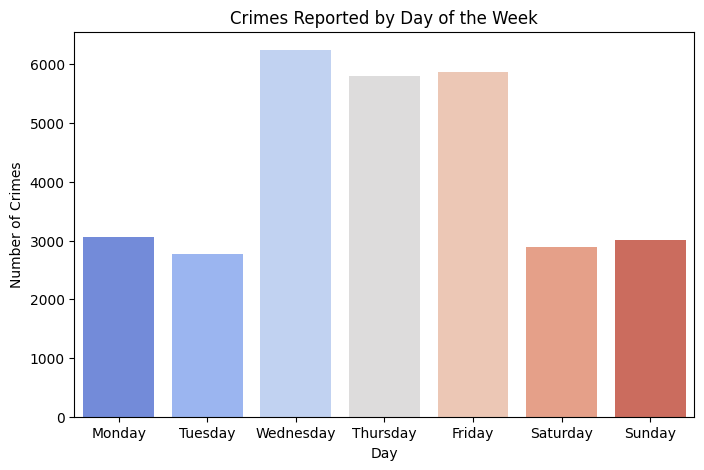

In [ ]:
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df['Day_of_Week'] = df['Month'].dt.day_name()
crime_by_day = df['Day_of_Week'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(8,5))
sns.barplot(x=crime_by_day.index, y=crime_by_day.values, palette='coolwarm')
plt.title('Crimes Reported by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Crimes')
plt.show()

In [ ]:
!pip install plotly
import plotly.express as px
fig = px.scatter_mapbox(df, lat="Latitude", lon="Longitude", hover_name="Crime type",
                        color="Crime type", zoom=5, height=700)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Crime Locations Map")
fig.show()

/tmp/ipython-input-182681272.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



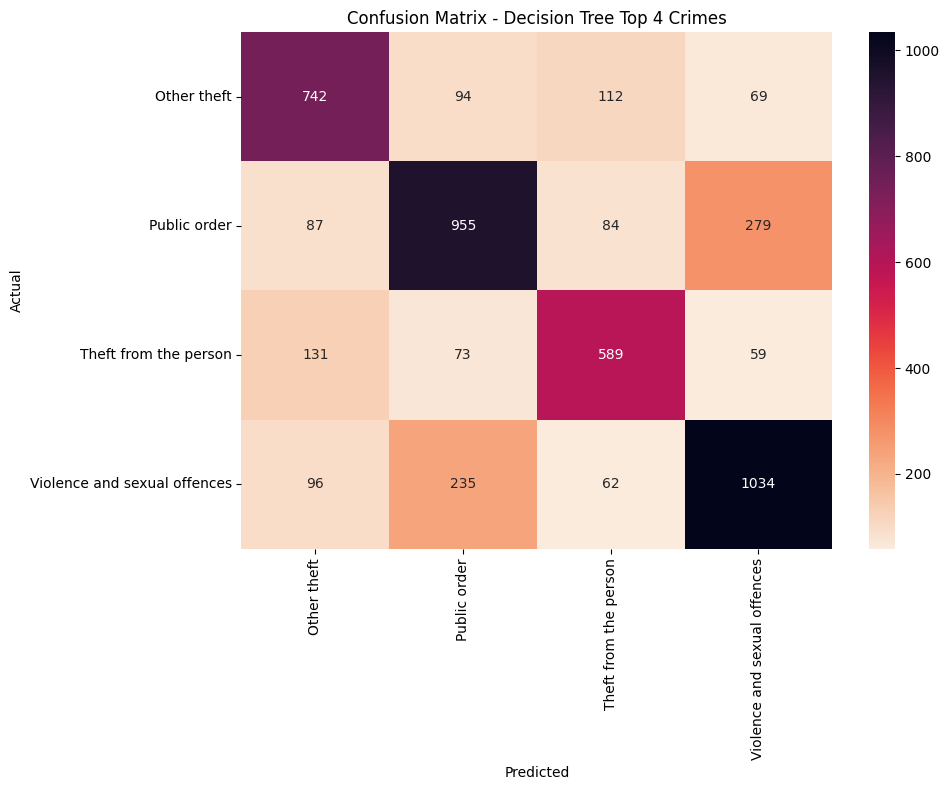

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
df = pd.read_csv("cleaned_uk_police_crime_data.csv")
top_crimes = df['Crime type'].value_counts().nlargest(4).index.tolist()
df_top = df[df['Crime type'].isin(top_crimes)]
le = LabelEncoder()
df_top['Crime type'] = le.fit_transform(df_top['Crime type'])
label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
X = df_top[['Longitude', 'Latitude']]
y = df_top['Crime type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels_sorted = [label_mapping[i] for i in sorted(label_mapping)]
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title('Confusion Matrix - Decision Tree Top 4 Crimes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2945999216.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



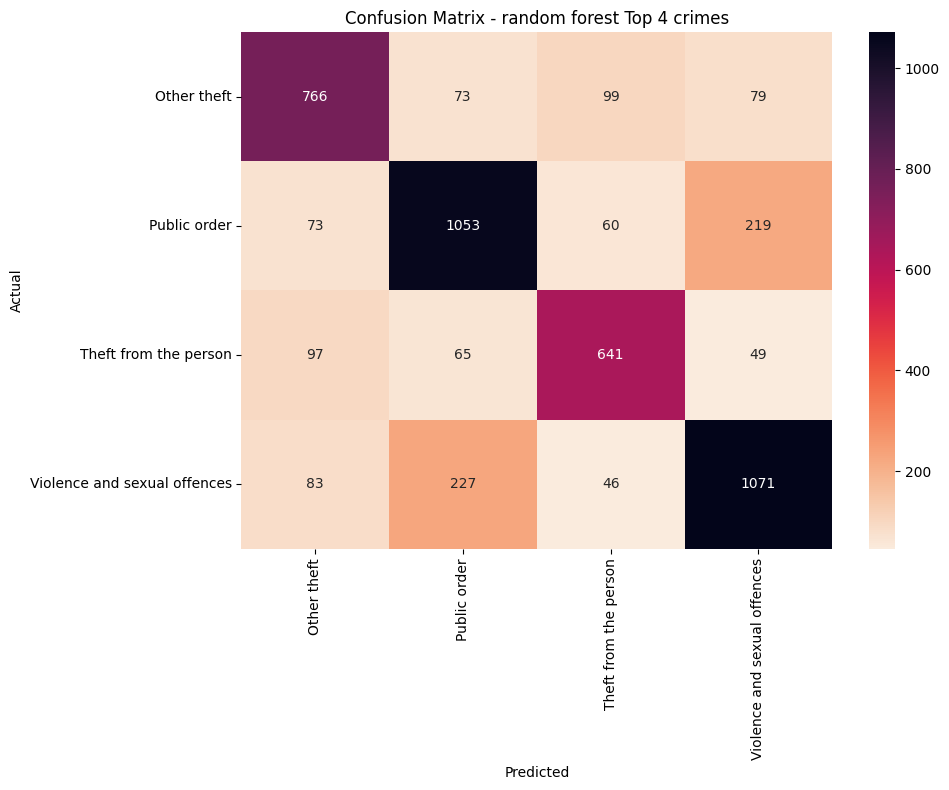

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
top_crimes = df['Crime type'].value_counts().nlargest(4).index.tolist()
df_top = df[df['Crime type'].isin(top_crimes)]
le = LabelEncoder()
df_top['Crime type'] = le.fit_transform(df_top['Crime type'])
label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
X = df_top[['Longitude', 'Latitude']]
y = df_top['Crime type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels_sorted = [label_mapping[i] for i in sorted(label_mapping)]
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title('Confusion Matrix - random forest Top 4 crimes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import files
df = pd.read_csv("cleaned_uk_police_crime_data.csv")
df = df.dropna(subset=['Latitude', 'Longitude'])
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df[['Latitude', 'Longitude']])
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['Cluster_7'] = kmeans.fit_predict(coords_scaled)
sample_df = df.sample(n=3000, random_state=42)
fig = px.scatter_mapbox(
    sample_df,
    lat="Latitude",
    lon="Longitude",
    color="Cluster_7",
    zoom=5,
    height=700,
    title=" Crime Hotspot Clusters in the UK (KMeans, k=7)",
    mapbox_style="carto-positron",
    hover_data=["Crime type", "Location", "Month"]
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("cleaned_uk_police_crime_data.csv")
top5_crimes = df['Crime type'].value_counts().nlargest(5).index.tolist()
df_top5 = df[df['Crime type'].isin(top5_crimes)].copy()
df_top5.dropna(subset=['Longitude', 'Latitude'], inplace=True)
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df_top5[['Longitude', 'Latitude']])
dbscan = DBSCAN(eps=0.15, min_samples=10)
df_top5['Cluster'] = dbscan.fit_predict(coords_scaled)
fig = px.scatter_mapbox(
    df_top5,
    lat='Latitude',
    lon='Longitude',
    color=df_top5['Cluster'].astype(str),
    zoom=5,
    height=600,
    title='Crime Hotspot Clusters using DBSCAN (Interactive Map)',
    mapbox_style='carto-positron'
)
fig.show()
